# DA-HGNN for Ethereum Phishing Detection

This notebook implements a **Data Augmentation Heterogeneous Graph Neural Network (DA-HGNN)** pipeline for detecting phishing nodes in Ethereum transaction data.

The architecture combines:
- **Conv1D branch** for local feature pattern extraction
- **GRU + Multi-Head Attention branch** for temporal dependency modeling
- **SAGEConv-based graph reconstruction encoder** for relational representation learning

Dataset used: `node_features_labeled.csv`

Target task: binary classification (`0 = benign`, `1 = phishing`).

In [ ]:
!pip install torch torch-geometric pandas numpy scikit-learn matplotlib seaborn tqdm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torch_geometric.nn import SAGEConv, GCNConv, GAE
from torch_geometric.data import Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.metrics.pairwise import cosine_similarity

from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Step 1 - Data Loading and Exploration

In [ ]:
def detect_label_column(df: pd.DataFrame) -> str:
    """Detect the label column, preferring a binary 0/1 column and falling back safely."""
    if 'label' in df.columns:
        return 'label'

    binary_candidates = []
    for col in df.columns:
        vals = df[col].dropna().unique()
        if len(vals) > 0 and set(vals).issubset({0, 1}):
            binary_candidates.append(col)

    if binary_candidates:
        return binary_candidates[-1]

    return df.columns[-1]


def detect_node_id_column(df: pd.DataFrame, label_col: str) -> str:
    """Detect node identifier column if available, otherwise create one."""
    if 'node_id' in df.columns:
        return 'node_id'

    id_like = [c for c in df.columns if 'id' in c.lower() and c != label_col]
    if id_like:
        return id_like[0]

    df['node_id'] = np.arange(len(df))
    return 'node_id'


df = pd.read_csv('node_features_labeled.csv')
label_col = detect_label_column(df)
node_id_col = detect_node_id_column(df, label_col)

print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
print('Detected label column:', label_col)
print('Detected node id column:', node_id_col)
display(df.head())
print('Class distribution:')
print(df[label_col].value_counts(dropna=False))

Dataset shape: (17623, 8)
Columns: ['address', 'in_degree', 'out_degree', 'total_in', 'total_out', 'balance', 'label', 'node_id']
Detected label column: label
Detected node id column: node_id


,address,in_degree,out_degree,total_in,total_out,balance,label,node_id
0,0xfdd3bfe92735e109726d397007464624a39334d7,0,1,0.000000,2.525248,-2.525248,0,0
1,0xd0cc2b24980cbcca47ef755da88b220a82291407,17,12,10.761346,6.827024,3.934322,1,1
2,0xd8711dba2db856eebd7f01db3d877e4c53d6dee2,1,1,0.095310,0.092714,0.002596,0,2
3,0x7e8def9b77417f60a5a6a420573f4580e14e17b1,1,3,2.831395,0.277897,2.553498,0,3
4,0x984a01719fceeedd10c43afca9d4220508e54f1a,4,4,7.786082,3.793805,3.992277,0,4


Class distribution:
label
0    17535
1       88
Name: count, dtype: int64


In [ ]:
def clean_dataset(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Remove duplicates and handle missing values for robust model training."""
    before = df.shape
    cleaned = df.drop_duplicates().copy()

    # Fill numeric missing values with 0 and drop rows where label is missing.
    numeric_cols = cleaned.select_dtypes(include=[np.number]).columns
    cleaned[numeric_cols] = cleaned[numeric_cols].fillna(0)
    cleaned = cleaned.dropna(subset=[label_col])

    after = cleaned.shape
    print('Shape before cleaning:', before)
    print('Shape after cleaning :', after)
    print('Class counts after cleaning:')
    print(cleaned[label_col].value_counts())
    return cleaned


df_clean = clean_dataset(df, label_col)

Shape before cleaning: (17623, 8)
Shape after cleaning : (17623, 8)
Class counts after cleaning:
label
0    17535
1       88
Name: count, dtype: int64


## Step 2 - Feature Engineering and Basic Features

In [ ]:
def extract_basic_features(df: pd.DataFrame, node_id_col: str, label_col: str):
    """Extract and standardize basic node features."""
    feature_cols = [c for c in df.columns if c not in [node_id_col, label_col]]
    basic = df[feature_cols].copy()

    # Ensure numeric conversion for model readiness.
    for c in basic.columns:
        basic[c] = pd.to_numeric(basic[c], errors='coerce').fillna(0)

    scaler = StandardScaler()
    basic_features_scaled = scaler.fit_transform(basic.values.astype(np.float32))

    return basic_features_scaled, feature_cols, scaler


basic_features, feature_cols, scaler = extract_basic_features(df_clean, node_id_col, label_col)
labels = df_clean[label_col].astype(int).values
node_ids = df_clean[node_id_col].values

print('Number of basic feature columns:', len(feature_cols))
print('Basic feature matrix shape:', basic_features.shape)

Number of basic feature columns: 6
Basic feature matrix shape: (17623, 6)


## Step 3 - Data Augmentation via Sliding Window

In [ ]:
def build_temporal_matrix_from_features(feature_vector: np.ndarray) -> np.ndarray:
    """Create a pseudo-temporal matrix by rolling feature values to model sequence dynamics."""
    num_features = feature_vector.shape[0]
    temporal_matrix = np.stack([np.roll(feature_vector, shift=i) for i in range(num_features)], axis=0)
    return temporal_matrix


def sliding_window_augment(features: np.ndarray, y: np.ndarray, node_ids: np.ndarray, window_size: int = 4, stride: int = 2):
    """Generate augmented time-series samples using sliding windows and minority balancing."""
    X_aug, y_aug, node_idx_aug, node_id_aug = [], [], [], []

    for idx in range(features.shape[0]):
        seq = build_temporal_matrix_from_features(features[idx])  # (num_features, num_features)

        # Pad if sequence length is shorter than window size.
        if seq.shape[0] < window_size:
            pad_len = window_size - seq.shape[0]
            seq = np.pad(seq, ((0, pad_len), (0, 0)), mode='constant')

        for start in range(0, seq.shape[0] - window_size + 1, stride):
            window = seq[start:start + window_size]
            X_aug.append(window.astype(np.float32))
            y_aug.append(int(y[idx]))
            node_idx_aug.append(idx)
            node_id_aug.append(node_ids[idx])

        # Ensure at least one sample per node.
        if (seq.shape[0] - window_size + 1) <= 0:
            fallback = np.zeros((window_size, seq.shape[1]), dtype=np.float32)
            valid_len = min(window_size, seq.shape[0])
            fallback[:valid_len] = seq[:valid_len]
            X_aug.append(fallback)
            y_aug.append(int(y[idx]))
            node_idx_aug.append(idx)
            node_id_aug.append(node_ids[idx])

    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.int64)
    node_idx_aug = np.array(node_idx_aug, dtype=np.int64)
    node_id_aug = np.array(node_id_aug)

    # Optional minority oversampling fallback after sliding windows.
    class_counts = np.bincount(y_aug, minlength=2)
    majority = int(np.argmax(class_counts))
    minority = 1 - majority
    gap = int(class_counts[majority] - class_counts[minority])

    if gap > 0 and class_counts[minority] > 0:
        minority_idx = np.where(y_aug == minority)[0]
        extra_idx = np.random.choice(minority_idx, size=gap, replace=True)

        # Add slight Gaussian noise to avoid exact duplicates.
        X_extra = X_aug[extra_idx] + np.random.normal(0, 0.01, size=X_aug[extra_idx].shape).astype(np.float32)
        y_extra = y_aug[extra_idx]
        node_idx_extra = node_idx_aug[extra_idx]
        node_id_extra = node_id_aug[extra_idx]

        X_aug = np.concatenate([X_aug, X_extra], axis=0)
        y_aug = np.concatenate([y_aug, y_extra], axis=0)
        node_idx_aug = np.concatenate([node_idx_aug, node_idx_extra], axis=0)
        node_id_aug = np.concatenate([node_id_aug, node_id_extra], axis=0)

    return X_aug, y_aug, node_idx_aug, node_id_aug


n = 4
stride = n // 2
X_time_series, y_augmented, node_idx_augmented, node_id_augmented = sliding_window_augment(
    basic_features, labels, node_ids, window_size=n, stride=stride
)

original_counts = pd.Series(labels).value_counts().sort_index()
aug_counts = pd.Series(y_augmented).value_counts().sort_index()

print('X_time_series shape:', X_time_series.shape)
print('Original class counts (0=benign,1=phishing):')
print(original_counts)
print('Augmented class counts (0=benign,1=phishing):')
print(aug_counts)

X_time_series shape: (70140, 4, 6)
Original class counts (0=benign,1=phishing):
0    17535
1       88
Name: count, dtype: int64
Augmented class counts (0=benign,1=phishing):
0    35070
1    35070
Name: count, dtype: int64


## Step 4 - Build Graph Structure

In [ ]:
def construct_graph_data(basic_features: np.ndarray, labels: np.ndarray) -> Data:
    """Construct a graph where phishing nodes connect to their 3 nearest neighbors by cosine similarity."""
    x = torch.tensor(basic_features, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.long)

    phishing_idx = np.where(labels == 1)[0]
    sim = cosine_similarity(basic_features)

    edges = set()
    k = 3

    for i in phishing_idx:
        nn_idx = np.argsort(-sim[i])
        nn_idx = [j for j in nn_idx if j != i][:k]
        for j in nn_idx:
            edges.add((i, j))
            edges.add((j, i))

    # Add self-loops to stabilize message passing.
    for i in range(len(labels)):
        edges.add((i, i))

    if not edges:
        edges = {(i, i) for i in range(len(labels))}

    edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()

    data = Data(x=x, edge_index=edge_index, y=y)
    return data


graph_data = construct_graph_data(basic_features, labels)
print(f'Number of nodes: {graph_data.num_nodes}')
print(f'Number of edges: {graph_data.edge_index.shape[1]}')

Number of nodes: 17623
Number of edges: 18117


## Step 5 - Model Architecture

In [ ]:
class Conv1DBlock(nn.Module):
    """Conv1D feature extractor with BN, LeakyReLU, and optional residual connection."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, padding: int = 1):
        """Initialize Conv1D block layers."""
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.act = nn.LeakyReLU(negative_slope=0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass returning OutConv1D features."""
        out = self.act(self.bn(self.conv(x)))
        if x.shape[1] == out.shape[1]:
            out = out + x
        return out

In [ ]:
class GRUWithMHA(nn.Module):
    """Two-stage GRU encoder with Multi-Head Attention for temporal dependency modeling."""

    def __init__(self, input_size: int, hidden_size: int, num_heads: int = 4):
        """Initialize GRU and MHA components."""
        super().__init__()
        self.gru1 = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.mha = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True)
        self.gru2 = nn.GRU(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass: GRU1 -> MHA(Q=K=V) -> GRU2."""
        out1, _ = self.gru1(x)
        attn_out, _ = self.mha(out1, out1, out1)
        out2, _ = self.gru2(attn_out)
        return out2

In [ ]:
class TemporalFeaturesModule(nn.Module):
    """Dual-branch temporal feature extractor combining Conv1D and GRU+MHA outputs."""

    def __init__(self, num_features: int, conv_channels: int = 32, gru_hidden: int = 32):
        """Initialize temporal branches and output dimensions."""
        super().__init__()
        self.conv_branch = Conv1DBlock(in_channels=num_features, out_channels=conv_channels)
        self.gru_mha_branch = GRUWithMHA(input_size=num_features, hidden_size=gru_hidden)
        self.out_dim = conv_channels + gru_hidden

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return concatenated temporal features from Conv1D and GRU+MHA branches."""
        # Equation (1) concept: Conv1D captures local receptive-field patterns over temporal windows.
        conv_in = x.permute(0, 2, 1)
        conv_out = self.conv_branch(conv_in)
        conv_pool = conv_out.mean(dim=2)

        # Equations (3)(4)(5) concept: self-attention with Q,K,V from GRU states to model long-range dependencies.
        gru_out = self.gru_mha_branch(x)
        gru_pool = gru_out.mean(dim=1)

        return torch.cat([conv_pool, gru_pool], dim=1)

In [ ]:
class SAGEConvReconstructionModule(nn.Module):
    """GraphSAGE encoder with inner-product reconstruction for graph structure learning."""

    def __init__(self, in_dim: int, hidden_dim: int = 64, out_dim: int = 32):
        """Initialize two-layer SAGEConv encoder."""
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """Return node embeddings z used by GAE-style inner-product reconstruction."""
        # Equation (6) concept: z = SAGEConv(SAGEConv(x, E), E), then A_hat approx sigma(zz^T).
        h = F.leaky_relu(self.conv1(x, edge_index), negative_slope=0.1)
        z = F.leaky_relu(self.conv2(h, edge_index), negative_slope=0.1)
        return z

    def reconstruct_adjacency(self, z: torch.Tensor) -> torch.Tensor:
        """Reconstruct adjacency logits with inner product decoder."""
        return torch.sigmoid(torch.matmul(z, z.t()))

In [ ]:
class DAHGNN(nn.Module):
    """Full DA-HGNN model combining temporal, graph, and basic feature representations."""

    def __init__(self, num_basic_features: int, temporal_seq_features: int, temporal_window: int,
                 temporal_conv_channels: int = 32, temporal_gru_hidden: int = 32,
                 graph_hidden_dim: int = 64, graph_out_dim: int = 32):
        """Initialize DA-HGNN submodules and binary classifier head."""
        super().__init__()
        self.temporal = TemporalFeaturesModule(
            num_features=temporal_seq_features,
            conv_channels=temporal_conv_channels,
            gru_hidden=temporal_gru_hidden
        )
        self.sage = SAGEConvReconstructionModule(
            in_dim=num_basic_features,
            hidden_dim=graph_hidden_dim,
            out_dim=graph_out_dim
        )

        combined_dim = num_basic_features + self.temporal.out_dim + graph_out_dim

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, time_series_input: torch.Tensor, node_features: torch.Tensor, edge_index: torch.Tensor,
                basic_features_batch: torch.Tensor, node_indices_batch: torch.Tensor) -> torch.Tensor:
        """Forward pass for DA-HGNN and binary phishing probability output."""
        temporal_feats = self.temporal(time_series_input)
        graph_embed_all = self.sage(node_features, edge_index)
        graph_embed_batch = graph_embed_all[node_indices_batch]
        combined = torch.cat([basic_features_batch, temporal_feats, graph_embed_batch], dim=1)
        return self.classifier(combined).squeeze(-1)


def count_parameters(model: nn.Module) -> int:
    """Count trainable parameters in a PyTorch model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


num_basic_features = basic_features.shape[1]
temporal_seq_features = X_time_series.shape[2]
temporal_window = X_time_series.shape[1]

model = DAHGNN(
    num_basic_features=num_basic_features,
    temporal_seq_features=temporal_seq_features,
    temporal_window=temporal_window
).to(device)

print(model)
print(f'Trainable parameters: {count_parameters(model):,}')

DAHGNN(
  (temporal): TemporalFeaturesModule(
    (conv_branch): Conv1DBlock(
      (conv): Conv1d(6, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1)
    )
    (gru_mha_branch): GRUWithMHA(
      (gru1): GRU(6, 32, batch_first=True)
      (mha): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      )
      (gru2): GRU(32, 32, batch_first=True)
    )
  )
  (sage): SAGEConvReconstructionModule(
    (conv1): SAGEConv(6, 64, aggr=mean)
    (conv2): SAGEConv(64, 32, aggr=mean)
  )
  (classifier): Sequential(
    (0): Linear(in_features=102, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Trainable parameters: 26,689


## Step 6 - Training Setup

In [ ]:
class TemporalGraphDataset(Dataset):
    """Dataset for augmented temporal samples with graph node mapping."""

    def __init__(self, X: np.ndarray, y: np.ndarray, node_idx: np.ndarray, basic_features: np.ndarray, node_ids: np.ndarray):
        """Store arrays needed for DA-HGNN batch training and evaluation."""
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.node_idx = node_idx.astype(np.int64)
        self.basic_features = basic_features.astype(np.float32)
        self.node_ids = node_ids

    def __len__(self):
        """Return number of samples."""
        return len(self.y)

    def __getitem__(self, idx):
        """Return one sample tuple for model input and tracking."""
        ni = self.node_idx[idx]
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32),
            torch.tensor(ni, dtype=torch.long),
            torch.tensor(self.basic_features[ni], dtype=torch.float32),
            self.node_ids[idx]
        )


indices = np.arange(len(y_augmented))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    indices, y_augmented, test_size=0.30, stratify=y_augmented, random_state=42
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'Train samples: {len(idx_train)}')
print(f'Val samples  : {len(idx_val)}')
print(f'Test samples : {len(idx_test)}')

train_dataset = TemporalGraphDataset(
    X_time_series[idx_train], y_augmented[idx_train], node_idx_augmented[idx_train], basic_features, node_id_augmented[idx_train]
)
val_dataset = TemporalGraphDataset(
    X_time_series[idx_val], y_augmented[idx_val], node_idx_augmented[idx_val], basic_features, node_id_augmented[idx_val]
)
test_dataset = TemporalGraphDataset(
    X_time_series[idx_test], y_augmented[idx_test], node_idx_augmented[idx_test], basic_features, node_id_augmented[idx_test]
)

batch_size = 64
train_class_counts = np.bincount(y_train.astype(int), minlength=2)
imbalance_ratio = (train_class_counts.max() / max(train_class_counts.min(), 1))

if imbalance_ratio > 1.1:
    class_weights = 1.0 / np.maximum(train_class_counts, 1)
    sample_weights = class_weights[y_train.astype(int)]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
    print('Using WeightedRandomSampler for class imbalance fallback.')
else:
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    print('Class distribution is close to balanced. Using shuffle=True.')

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train samples: 49098
Val samples  : 10521
Test samples : 10521
Class distribution is close to balanced. Using shuffle=True.


In [ ]:
def evaluate_loss(model: nn.Module, loader: DataLoader, node_features: torch.Tensor, edge_index: torch.Tensor, criterion) -> float:
    """Compute average loss on a dataloader without gradient updates."""
    model.eval()
    losses = []
    with torch.no_grad():
        for X_batch, y_batch, node_idx_batch, basic_batch, _ in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            node_idx_batch = node_idx_batch.to(device)
            basic_batch = basic_batch.to(device)

            probs = model(X_batch, node_features, edge_index, basic_batch, node_idx_batch)
            loss = criterion(probs, y_batch)
            losses.append(loss.item())

    return float(np.mean(losses)) if losses else 0.0


optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.BCELoss()
num_epochs = 50
best_val_loss = float('inf')
best_model_path = 'best_dahgnn_model.pt'

node_features_tensor = graph_data.x.to(device)
edge_index_tensor = graph_data.edge_index.to(device)

train_losses, val_losses = [], []

epoch_bar = tqdm(range(1, num_epochs + 1), desc='Training epochs')
for epoch in epoch_bar:
    model.train()
    batch_losses = []

    train_batch_bar = tqdm(train_loader, desc=f'Epoch {epoch}', leave=False)
    for X_batch, y_batch, node_idx_batch, basic_batch, _ in train_batch_bar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        node_idx_batch = node_idx_batch.to(device)
        basic_batch = basic_batch.to(device)

        optimizer.zero_grad()
        probs = model(X_batch, node_features_tensor, edge_index_tensor, basic_batch, node_idx_batch)
        loss = criterion(probs, y_batch)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = float(np.mean(batch_losses)) if batch_losses else 0.0
    val_loss = evaluate_loss(model, val_loader, node_features_tensor, edge_index_tensor, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    epoch_bar.set_postfix({'train_loss': f'{train_loss:.4f}', 'val_loss': f'{val_loss:.4f}'})

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    if epoch % 5 == 0:
        print(f'Epoch [{epoch:02d}/{num_epochs}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}')

print(f'Best model saved to: {best_model_path} with val loss = {best_val_loss:.4f}')

Training epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/768 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/768 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/768 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/768 [00:00<?, ?it/s]

...

Epoch 47:   0%|          | 0/768 [00:00<?, ?it/s]

Epoch 48:   0%|          | 0/768 [00:00<?, ?it/s]

Epoch 49:   0%|          | 0/768 [00:00<?, ?it/s]

Epoch 50:   0%|          | 0/768 [00:00<?, ?it/s]

Epoch [50/50]  Train Loss: 0.1468  Val Loss: 0.1604
Best model saved to: best_dahgnn_model.pt with val loss = 0.1426


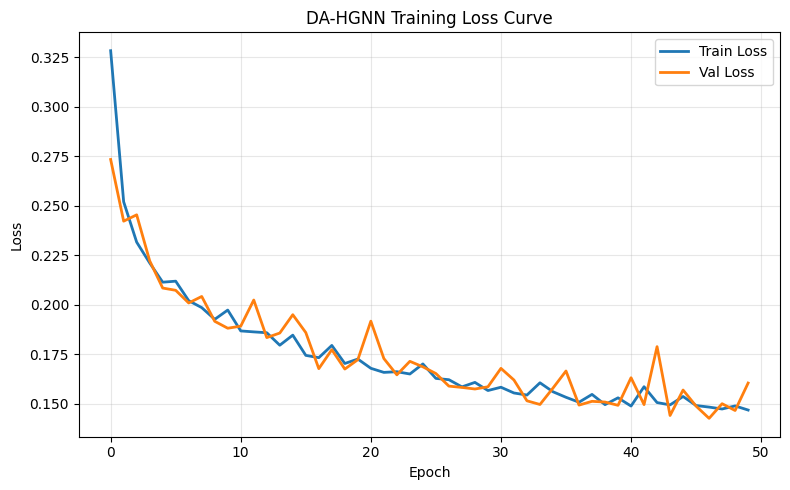

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DA-HGNN Training Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dahgnn_training_loss_curve.png', dpi=300)
plt.show()

## Step 7 - Evaluation

In [ ]:
def safe_div(num: float, den: float) -> float:
    """Safely divide two values and avoid zero-division errors."""
    return float(num / den) if den != 0 else 0.0


model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_probs = []
all_preds = []
all_true = []
all_node_ids = []

with torch.no_grad():
    for X_batch, y_batch, node_idx_batch, basic_batch, node_id_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        node_idx_batch = node_idx_batch.to(device)
        basic_batch = basic_batch.to(device)

        probs = model(X_batch, node_features_tensor, edge_index_tensor, basic_batch, node_idx_batch)
        preds = (probs >= 0.5).long()

        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_true.extend(y_batch.cpu().numpy().astype(int).tolist())
        all_node_ids.extend(list(node_id_batch))

y_true_test = np.array(all_true)
y_pred_test = np.array(all_preds)
y_prob_test = np.array(all_probs)
node_ids_test = np.array(all_node_ids)

acc = accuracy_score(y_true_test, y_pred_test)
prec = precision_score(y_true_test, y_pred_test, zero_division=0)
rec = recall_score(y_true_test, y_pred_test, zero_division=0)
f1 = f1_score(y_true_test, y_pred_test, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1]).ravel()
fpr = safe_div(fp, fp + tn)
fnr = safe_div(fn, fn + tp)

try:
    auc_roc = roc_auc_score(y_true_test, y_prob_test)
except Exception:
    auc_roc = float('nan')

try:
    auc_pr = average_precision_score(y_true_test, y_prob_test)
except Exception:
    auc_pr = float('nan')

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'FPR', 'FNR', 'AUC-ROC', 'AUC-PR'],
    'Value': [acc, prec, rec, f1, fpr, fnr, auc_roc, auc_pr]
})

print('Test Metrics:')
display(metrics_table.style.format({'Value': '{:.4f}'}))

Test Metrics:


,Metric,Value
0,Accuracy,0.9411
1,Precision,0.9569
2,Recall,0.9238
3,F1-Score,0.9400
4,FPR,0.0416
5,FNR,0.0762
6,AUC-ROC,0.9863
7,AUC-PR,0.9872


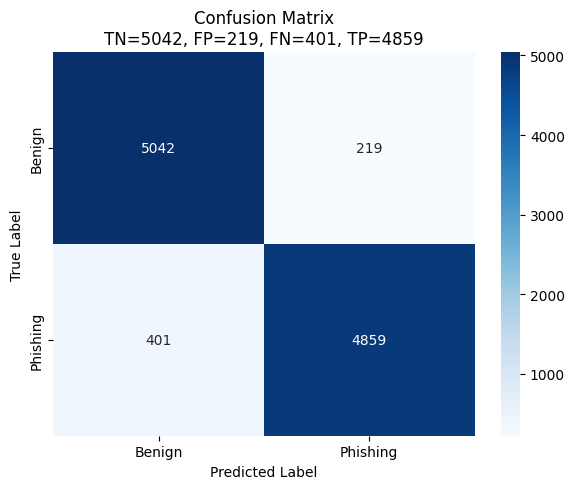

In [ ]:
cm = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Phishing'],
            yticklabels=['Benign', 'Phishing'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix\nTN={tn}, FP={fp}, FN={fn}, TP={tp}')
plt.tight_layout()
plt.savefig('dahgnn_confusion_matrix.png', dpi=300)
plt.show()

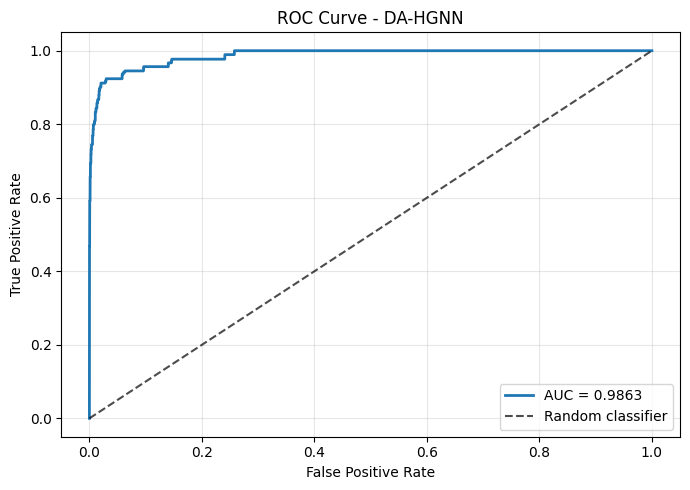

In [ ]:
plt.figure(figsize=(7, 5))
try:
    fpr_curve, tpr_curve, _ = roc_curve(y_true_test, y_prob_test)
    plt.plot(fpr_curve, tpr_curve, linewidth=2, label=f'AUC = {auc_roc:.4f}')
except Exception:
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='ROC unavailable')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.7, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DA-HGNN')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dahgnn_roc_curve.png', dpi=300)
plt.show()

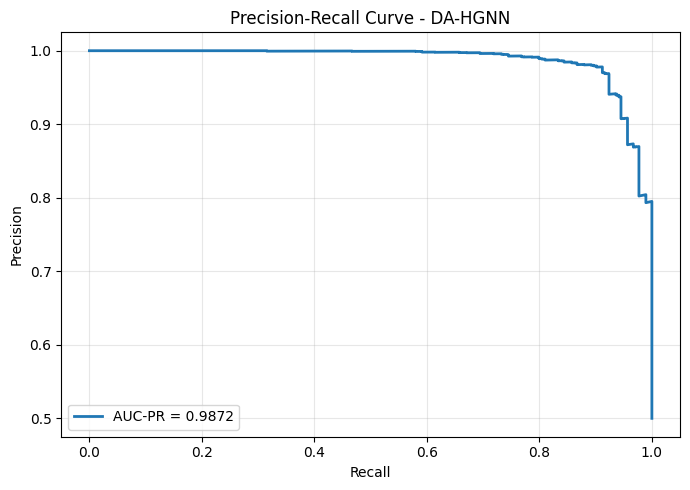

In [ ]:
plt.figure(figsize=(7, 5))
try:
    precision_curve, recall_curve, _ = precision_recall_curve(y_true_test, y_prob_test)
    plt.plot(recall_curve, precision_curve, linewidth=2, label=f'AUC-PR = {auc_pr:.4f}')
except Exception:
    plt.plot([0, 1], [1, 0], linestyle='--', color='gray', label='PR unavailable')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - DA-HGNN')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dahgnn_pr_curve.png', dpi=300)
plt.show()

## Step 8 - Results Summary

This DA-HGNN implementation used:
- **Temporal module**: Conv1D + GRU + Multi-Head Attention for local and long-range dependency extraction
- **Graph module**: Two-layer SAGEConv encoder with GAE-style reconstruction intuition
- **Classifier**: MLP head over concatenated basic + temporal + graph embeddings

Dataset details:
- Source: `node_features_labeled.csv`
- Task: Binary phishing node detection (`0 = benign`, `1 = phishing`)
- Data augmentation: Sliding window (n=4, stride=2) with minority oversampling fallback

Interpretation of module contributions:
- Conv1D branch captures short-range local patterns in transformed temporal windows
- GRU+MHA branch captures global temporal dependencies and contextual weighting
- SAGEConv branch injects relational information from node neighborhoods

Final quantitative results are shown in the metrics table above (Accuracy, Precision, Recall, F1, FPR, FNR, AUC-ROC, AUC-PR).

In [ ]:
metrics_table.to_csv('results_summary.csv', index=False)

predictions_df = pd.DataFrame({
    'node_id': node_ids_test,
    'true_label': y_true_test,
    'predicted_label': y_pred_test,
    'predicted_prob': y_prob_test
})
predictions_df.to_csv('predictions.csv', index=False)

print('Saved: results_summary.csv')
print('Saved: predictions.csv')
print('Saved plots:')
print('- dahgnn_training_loss_curve.png')
print('- dahgnn_confusion_matrix.png')
print('- dahgnn_roc_curve.png')
print('- dahgnn_pr_curve.png')

Saved: results_summary.csv
Saved: predictions.csv
Saved plots:
- dahgnn_training_loss_curve.png
- dahgnn_confusion_matrix.png
- dahgnn_roc_curve.png
- dahgnn_pr_curve.png
